# Aufgabe 3

In Aufgabe zwei wurde dass Inferferenzmuster von zwei verscheidnene LEDs, bei uns einer grünen und roten LED. Es wurden vier Interferenzmuster als Bilderaufgenommen. Mit der gleichen Software die in Aufgabe 1 und 2 benutzt wurde.

Um die Abstände in der Software zu kallebrieren, wurde viermal, das Bild um 1mm verschoben. Dabei wurde ein bestimmter Punkt, oftmals ein Staubkorn oder eine andere Verschmutzung genommen und die Pixel zwischen den Punkt bei 77mm und 78mm ermittelt in dem Bild. So erhält man, das Verhältnis zwischen Pixel und Millimeter um die Daten auswerten zu können.

Messung| Tischpos [mm] |Pixel x-Achse | Pixel y-Achse | Tischpos [mm] | Pixel x-Achse | Pixel y-Achse | x-Abstand |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
1|77|2.153|1.113|78|1.386|1.110|767
2|77|1.701|971|78|931|965|770
3|77|2.131|635|78|1.368|629|763
4|77|1.907|1.713|78|1.137|1.704|770

**Hier fehlen noch unsicherheiten**

: Die ermittelten Pixelpositionen der Orientierungspunkte bei den Tsichpositionen 77mm und 78mm

Wenn wir den Mittelwert nehmen, des x-Abstands aus der Tabelle. Erhalten wir, dass vorlgende Verhältnis von Pixel zu Millimeter.

$$1\text{mm} \overset{\wedge}{=} 767.5 ~\text{Pixel}$$

Wir wollten eigentlich ursprünglich 5 Messungen machen, jedoch war dies nicht zu bewerkstelligen. Da die Software und Kamera immer wieder keine Bilder gezeigt haben oder gar ganz eingefrohren sind.

**Maybe noch DIagramm**

#### Ermittelte Beugungsbilder für die LEDs
![Beugungsbild der roten LED, mit dem ersten Maxima zentriert](./O9_Messdaten/Aufgabe_3_1.jpg)
![Beugungsbild der roten LED, mit vielen Maxima und Minimas](./O9_Messdaten/Aufgabe_3_2.jpg)
![Beugungsbild der grünen LED, mit dem ersten Maxima zentriert](./O9_Messdaten/Aufgabe_3_3.jpg)
![Beugungsbild der grünen LED, mit vielen Maxima und Minimas](./O9_Messdaten/Aufgabe_3_4.jpg)

**TODO: Maßstaab hinzufügen, Erkentlich machen wie gemessen wurde.**

#### Diagramm mit den Intensitäten und dem Fit

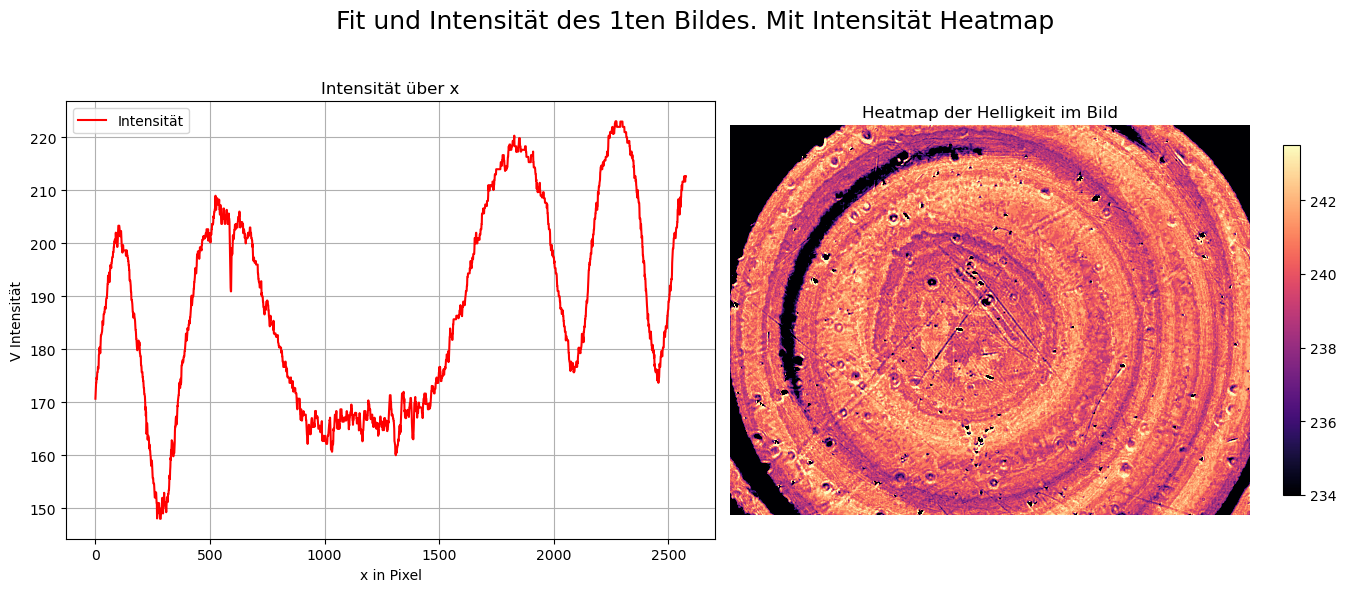

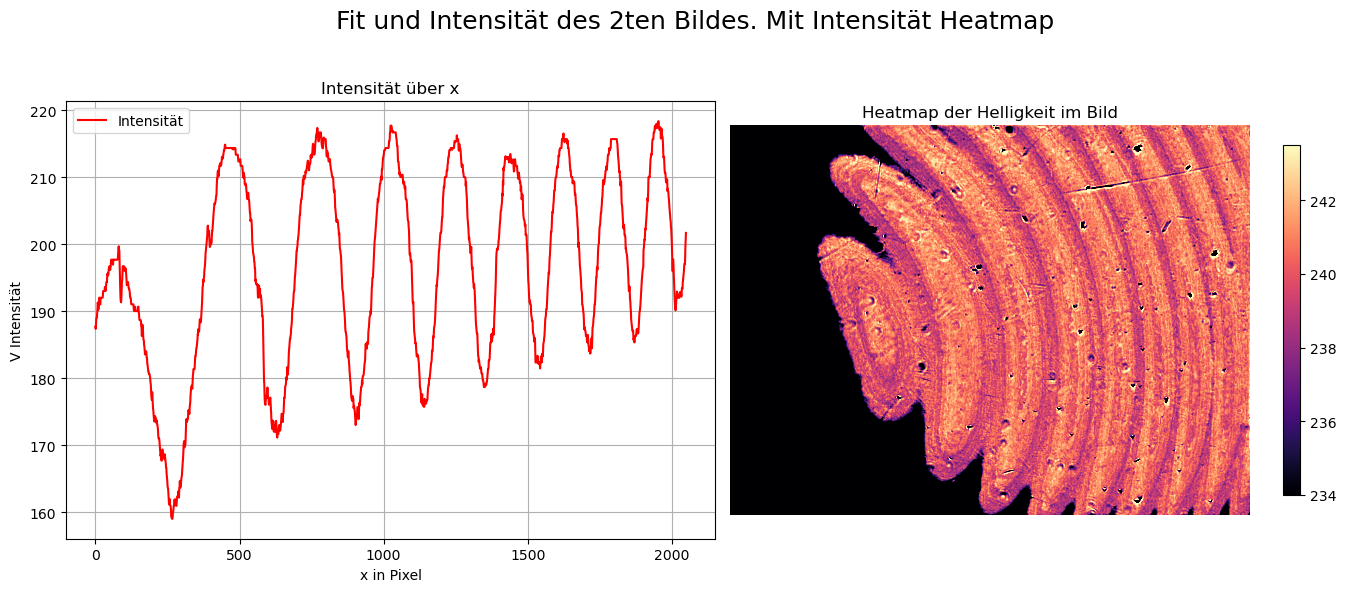

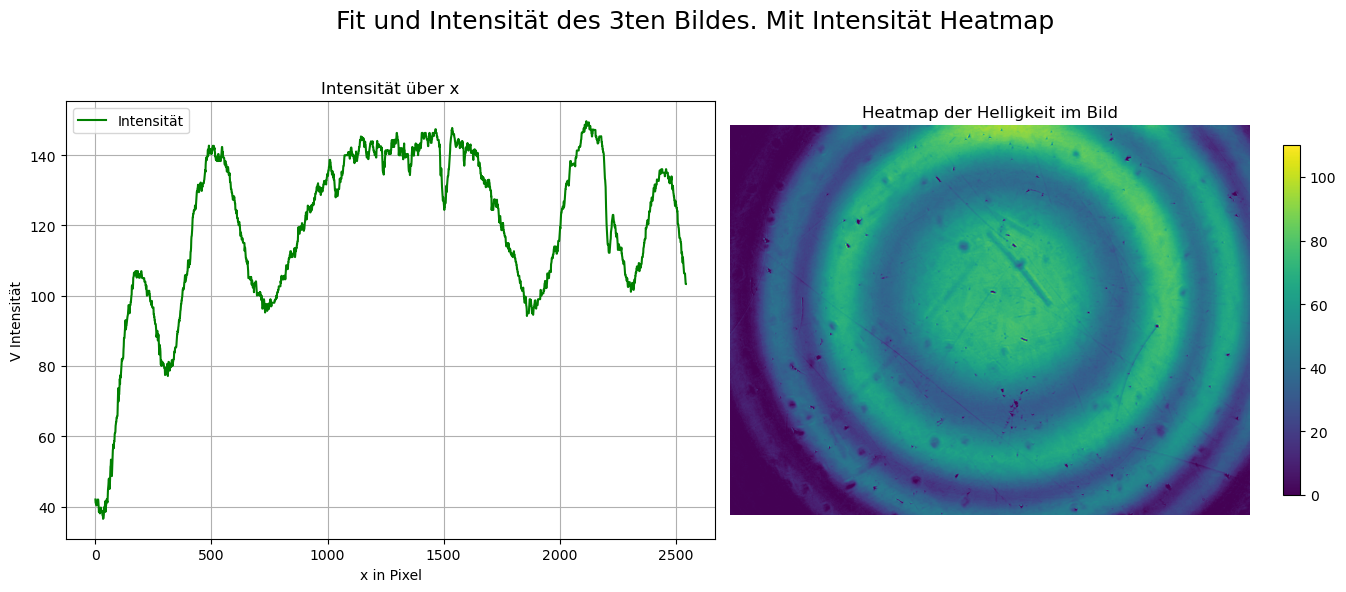

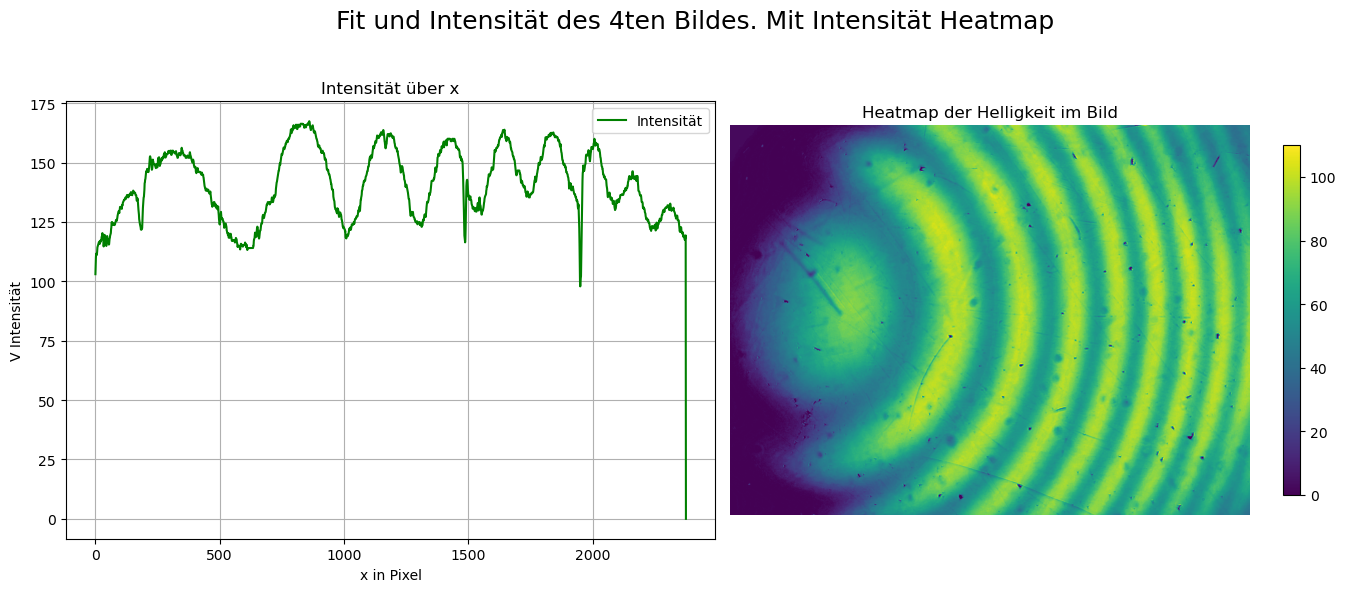

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

for i in range(4):
    df = pd.read_csv(f"./O9_Messdaten/Values_{i+1}.csv", sep="\t")
    img = np.asarray(Image.open(f"./O9_Messdaten/Aufgabe_3_{i+1}.jpg"))
    lum_img = img[:, :, 0] # Luminosity

    LED = "roter" if i < 2 else "grüner"

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Fit und Intensität des {i+1}ten Bildes. Mit Intensität Heatmap", fontsize=18)

    # linkes Plot: Intensität über x
    ax0 = axes[0]
    ax0.plot(df['X'], df['Y'], label="Intensität", color=LED[0])
    ax0.set_title("Intensität über x")
    ax0.set_xlabel("x in Pixel")
    ax0.set_ylabel("V Intensität")
    ax0.grid(True)
    ax0.legend()

    # rechtes Plot: Heatmap der Helligkeit
    ax1 = axes[1]
    im = ax1.imshow(lum_img, cmap=("magma" if i < 2 else "viridis"))
    ax1.set_title("Heatmap der Helligkeit im Bild")
    ax1.axis("off")
    if i < 2:
        im.set_clim(234, 243.5)
    else:
        im.set_clim(0, 110)
    fig.colorbar(im, ax=ax1, shrink=0.8)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


## Fehlerbetrachtung
**Klassische Feherbetrachtung** (Nicht genaues MEssen, schumtzgige Linesn, kein perfekter aufbau, und die Kamera war um 1px auf 1mm angeschrägt, aber dass war nicht korrigierbar weil sonnst wahrscheinlich eine größer abweichung passiert wäre)

Man muss zudem auch noch erwähnen, dass es nicht einfach war die Interferenzmuster wirklich sichbar zu machen, da wir nicht genau gewusst hatten wo genau sich die Diode in der LED befand. Mussen wir die Apperatur wodie LEDs befestigt waren, sehr lange verschieben und drehen um den richtigen Winkel bekommen. Uns ist zudem aufgefallen, dass die LED die besten Muster gegeben hatte, wenn die leicht schräg von oben auf die Linsen draufgeschienen hat.
Zudem hatten wir sehr lange Probleme überhaupt Interferenzmuster zu erhalten, bei den zwei LEDs. Erst nach mehrmaligen Wechseln der Linsen und neustarts der Software gelang es uns die guten Bilder zu machen.